In [1]:
import scanpy as sc
import squidpy as sq
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

sc.settings.verbosity = 3
sc.settings.figdir = '/rds/general/user/ys5320/home/scrna_project/figures/'

DATA_DIR = '/rds/general/user/ys5320/home/scrna_project/data/spatial_wu2021/'
RESULTS_DIR = '/rds/general/user/ys5320/home/scrna_project/results/'

# sample info
samples = {
    'CID4465':  'TNBC',
    'CID44971': 'TNBC',
    '1142243F': 'TNBC',
    '1160920F': 'TNBC',
    'CID4290':  'ER+',
    'CID4535':  'ER+'
}

print(f"Squidpy version: {sq.__version__}")
print(f"Scanpy version: {sc.__version__}")

Squidpy version: 1.8.1
Scanpy version: 1.11.5


/tmp/ipykernel_2082000/2404599710.py:25: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  print(f"Scanpy version: {sc.__version__}")


In [9]:
def load_visium_sample(sample_id, data_dir, samples_dict):
    sample_dir = data_dir + f'filtered_count_matrices/{sample_id}_filtered_count_matrix/'
    spatial_dir = data_dir + f'spatial/{sample_id}_spatial/'
    meta_path = data_dir + f'metadata/{sample_id}_metadata.csv'
    
    # load matrix
    matrix = csr_matrix(mmread(sample_dir + 'matrix.mtx').T)
    barcodes = pd.read_csv(sample_dir + 'barcodes.tsv', header=None)[0].values
    features = pd.read_csv(sample_dir + 'features.tsv', header=None, sep='\t')
    
    # create AnnData
    adata = ad.AnnData(X=matrix)
    adata.obs_names = barcodes
    adata.var_names = features[0].values
    adata.var_names_make_unique()
    
    # add metadata
    meta = pd.read_csv(meta_path, index_col=0)
    adata.obs = adata.obs.join(meta)
    
    # add spatial coordinates
    positions = pd.read_csv(
        spatial_dir + 'tissue_positions_list.csv',
        header=None,
        names=['barcode', 'in_tissue', 'array_row', 'array_col', 'pxl_row', 'pxl_col'],
        index_col='barcode'
    )
    common = adata.obs_names.intersection(positions.index)
    adata = adata[common].copy()
    adata.obsm['spatial'] = positions.loc[common, ['pxl_col', 'pxl_row']].values
    
    # add sample info
    adata.obs['sample_id'] = sample_id
    adata.obs['subtype'] = samples_dict[sample_id]
    
    # remove artefact spots
    adata = adata[adata.obs['Classification'] != 'Artefact'].copy()
    
    return adata

# load all samples
adatas = {}
for sample_id in samples.keys():
    print(f"Loading {sample_id}...")
    adatas[sample_id] = load_visium_sample(sample_id, DATA_DIR, samples)
    print(f"  {adatas[sample_id].n_obs} spots x {adatas[sample_id].n_vars} genes")

print("\nAll samples loaded!")

Loading CID4465...
  1207 spots x 19237 genes
Loading CID44971...
  1161 spots x 19237 genes
Loading 1142243F...
  4665 spots x 28402 genes
Loading 1160920F...
  4847 spots x 28402 genes
Loading CID4290...
  2425 spots x 19237 genes
Loading CID4535...
  1104 spots x 19237 genes

All samples loaded!


In [10]:
# merge all samples
adata_merged = ad.concat(
    list(adatas.values()),
    label='sample_id',
    keys=list(adatas.keys()),
    join='inner'
)

print(f"Merged: {adata_merged.n_obs} spots x {adata_merged.n_vars} genes")
print(f"\nSample counts:")
print(adata_merged.obs['sample_id'].value_counts())
print(f"\nSubtype counts:")
print(adata_merged.obs['subtype'].value_counts())
print(f"\nClassification counts:")
print(adata_merged.obs['Classification'].value_counts())

Merged: 15409 spots x 18714 genes

Sample counts:
sample_id
1160920F    4847
1142243F    4665
CID4290     2425
CID4465     1207
CID44971    1161
CID4535     1104
Name: count, dtype: int64

Subtype counts:
subtype
TNBC    11880
ER+      3529
Name: count, dtype: int64

Classification counts:
Classification
Invasive cancer + stroma + lymphocytes            8119
Invasive cancer + stroma                          2082
Stroma                                            2075
Invasive cancer + lymphocytes                      678
Necrosis                                           568
Invasive cancer                                    418
Lymphocytes                                        351
DCIS                                               285
Normal glands + lymphocytes                        278
Normal + stroma + lymphocytes                      240
Stroma + adipose tissue                            114
Adipose tissue                                      91
Uncertain                         

/rds/general/user/ys5320/home/anaconda3/envs/scrna/lib/python3.11/site-packages/anndata/_core/anndata.py:1878: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [11]:
# QC
adata_merged.var['mt'] = adata_merged.var_names.str.startswith('MT-')
sc.pp.calculate_qc_metrics(adata_merged, qc_vars=['mt'], 
                            percent_top=None, log1p=False, inplace=True)

print("Before filtering:", adata_merged.n_obs)
adata_merged = adata_merged[adata_merged.obs['n_genes_by_counts'] > 200, :]
adata_merged = adata_merged[adata_merged.obs['pct_counts_mt'] < 25, :]
print("After filtering:", adata_merged.n_obs)

Before filtering: 15409
After filtering: 15397


In [12]:
# normalise
sc.pp.normalize_total(adata_merged, target_sum=1e4)
sc.pp.log1p(adata_merged)
adata_merged.raw = adata_merged

# HVG
sc.pp.highly_variable_genes(adata_merged, min_mean=0.0125, max_mean=3, min_disp=0.5)
print(f"HVGs: {adata_merged.var['highly_variable'].sum()}")

adata_merged = adata_merged[:, adata_merged.var['highly_variable']].copy()

# scale and PCA
sc.pp.scale(adata_merged, max_value=10)
sc.tl.pca(adata_merged, svd_solver='arpack', n_comps=50)

# batch correct across samples
import harmonypy as hm
import numpy as np
ho = hm.run_harmony(
    adata_merged.obsm['X_pca'].astype(np.float64),
    adata_merged.obs,
    'sample_id'
)
adata_merged.obsm['X_pca_harmony'] = ho.Z_corr.astype(np.float64)

# UMAP and clustering
sc.pp.neighbors(adata_merged, n_neighbors=15, n_pcs=30, use_rep='X_pca_harmony')
sc.tl.umap(adata_merged)
sc.tl.leiden(adata_merged, resolution=0.3, key_added='leiden')

print(f"Clusters: {adata_merged.obs['leiden'].nunique()}")

/rds/general/user/ys5320/home/anaconda3/envs/scrna/lib/python3.11/site-packages/scanpy/preprocessing/_normalization.py:269: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)
/rds/general/user/ys5320/home/anaconda3/envs/scrna/lib/python3.11/site-packages/anndata/_core/anndata.py:1878: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


normalizing counts per cell
    finished (0:00:01)
extracting highly variable genes
    finished (0:00:03)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)
HVGs: 3060


/rds/general/user/ys5320/home/anaconda3/envs/scrna/lib/python3.11/site-packages/anndata/_core/anndata.py:1878: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/rds/general/user/ys5320/home/anaconda3/envs/scrna/lib/python3.11/functools.py:909: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


computing PCA
    with n_comps=50
    finished (0:01:13)


2026-05-20 02:37:32,570 - harmonypy - INFO - Running Harmony
2026-05-20 02:37:32,571 - harmonypy - INFO -   Parameters:
2026-05-20 02:37:32,571 - harmonypy - INFO -     max_iter_harmony: 10
2026-05-20 02:37:32,572 - harmonypy - INFO -     max_iter_kmeans: 4
2026-05-20 02:37:32,572 - harmonypy - INFO -     epsilon_cluster: 0.001
2026-05-20 02:37:32,572 - harmonypy - INFO -     epsilon_harmony: 0.01
2026-05-20 02:37:32,573 - harmonypy - INFO -     nclust: 100
2026-05-20 02:37:32,573 - harmonypy - INFO -     block_size: 0.05
2026-05-20 02:37:32,573 - harmonypy - INFO -     lamb: dynamic (alpha=0.2)
2026-05-20 02:37:32,574 - harmonypy - INFO -     theta: [2. 2. 2. 2. 2. 2.]
2026-05-20 02:37:32,574 - harmonypy - INFO -     sigma: [0.1 0.1 0.1 0.1 0.1]...
2026-05-20 02:37:32,574 - harmonypy - INFO -     verbose: True
2026-05-20 02:37:32,575 - harmonypy - INFO -     random_state: 0
2026-05-20 02:37:32,575 - harmonypy - INFO -   Data: 50 PCs × 15397 cells
2026-05-20 02:37:32,575 - harmonypy - 

computing neighbors
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:43)
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:00:39)
running Leiden clustering


/tmp/ipykernel_2082000/3428169857.py:29: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata_merged, resolution=0.3, key_added='leiden')


    finished: found 9 clusters and added
    'leiden', the cluster labels (adata.obs, categorical) (0:00:04)
Clusters: 9


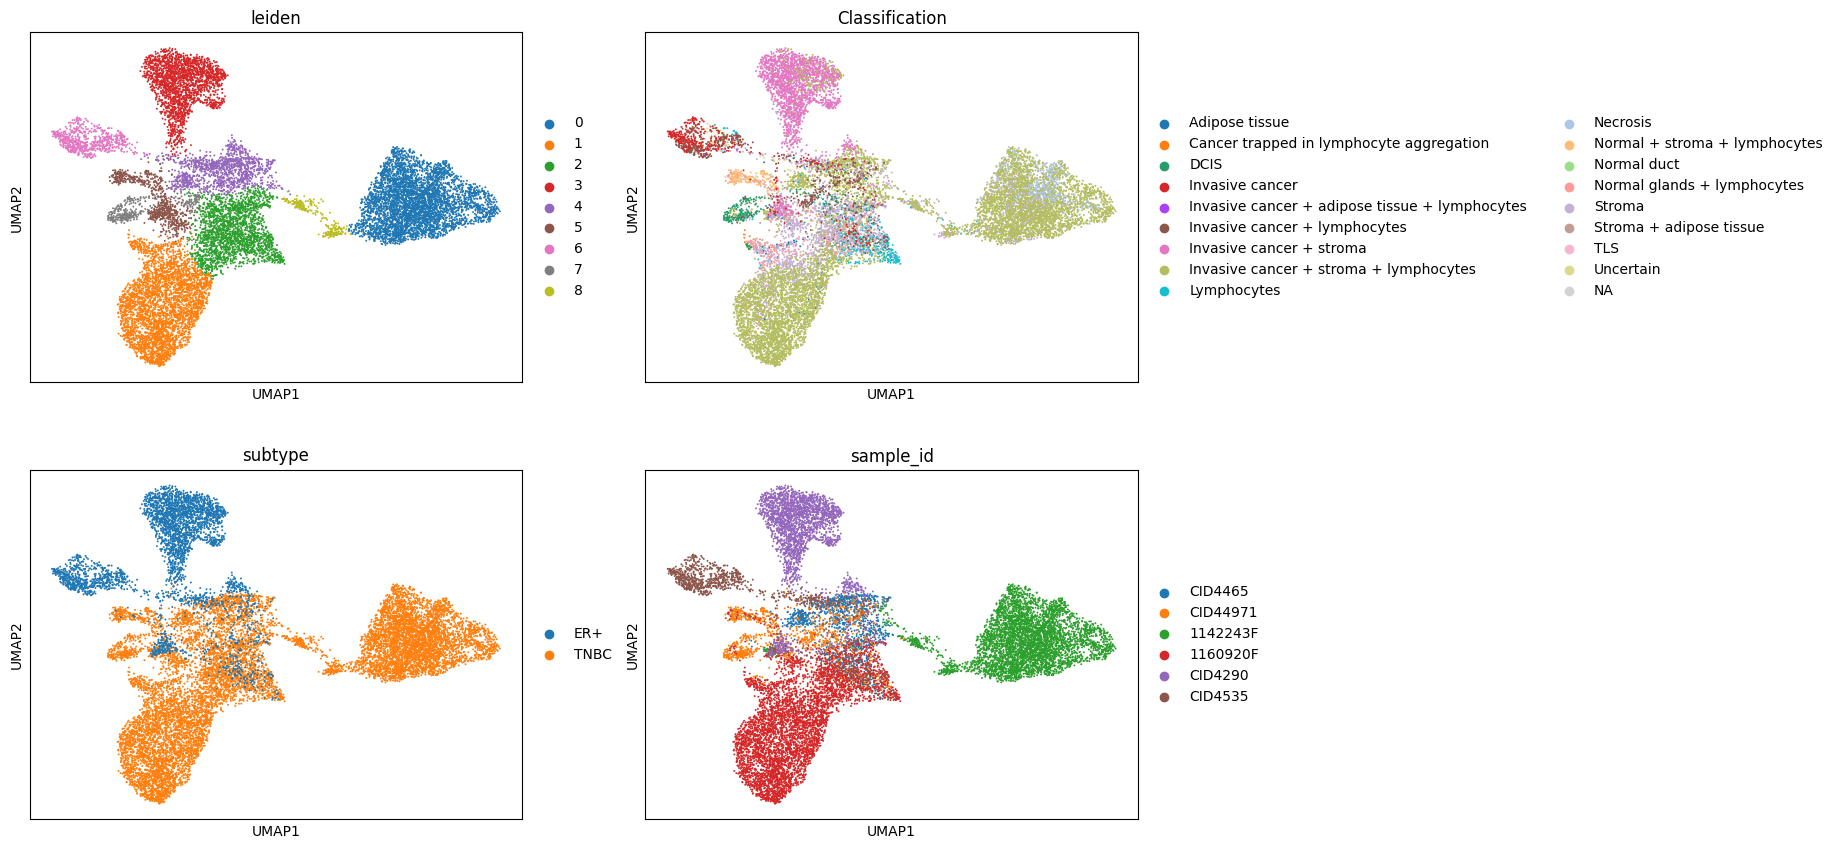

In [13]:
# fix duplicate obs names
adata_merged.obs_names_make_unique()

# plot UMAP
sc.pl.umap(adata_merged,
           color=['leiden', 'Classification', 'subtype', 'sample_id'],
           ncols=2,
           save='_umap_spatial.png')

normalizing counts per cell
    finished (0:00:00)


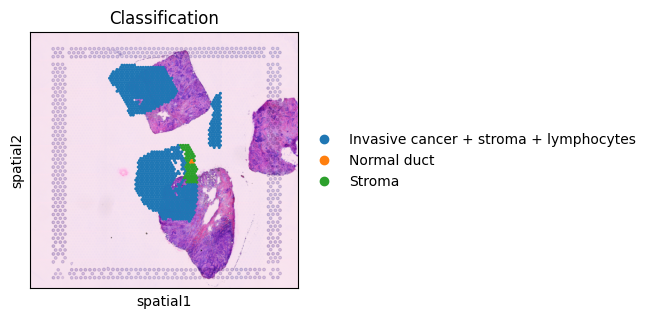

In [14]:
# visualise on tissue for one TNBC sample
sample = 'CID4465'
adata_sample = adatas[sample]

# normalise the individual sample for plotting
sc.pp.normalize_total(adata_sample, target_sum=1e4)
sc.pp.log1p(adata_sample)

# add spatial info to uns for squidpy plotting
adata_sample.uns['spatial'] = {
    sample: {
        'images': {
            'hires': plt.imread(
                DATA_DIR + f'spatial/{sample}_spatial/tissue_hires_image.png'
            )
        },
        'scalefactors': {
            'tissue_hires_scalef': 0.17,
            'spot_diameter_fullres': 89.4
        }
    }
}
adata_sample.obs['array_row'] = adatas[sample].obsm['spatial'][:, 1]
adata_sample.obs['array_col'] = adatas[sample].obsm['spatial'][:, 0]

# plot classification on tissue
sq.pl.spatial_scatter(adata_sample,
                      library_id=sample,
                      color='Classification',
                      img=True,
                      size=1.5,
                      save='spatial_classification_CID4465.png')

In [15]:
import json

with open(DATA_DIR + f'spatial/{sample}_spatial/scalefactors_json.json') as f:
    scalefactors = json.load(f)
print(scalefactors)

{'spot_diameter_fullres': 71.01023291740488, 'tissue_hires_scalef': 0.20729685, 'fiducial_diameter_fullres': 114.70883778965404, 'tissue_lowres_scalef': 0.062189054}


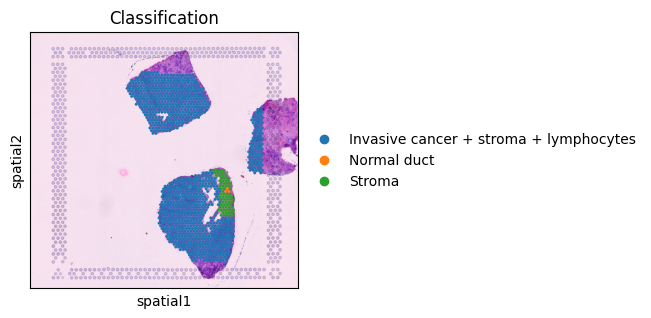

In [16]:
# update with correct scale factors
adata_sample.uns['spatial'] = {
    sample: {
        'images': {
            'hires': plt.imread(
                DATA_DIR + f'spatial/{sample}_spatial/tissue_hires_image.png'
            )
        },
        'scalefactors': {
            'tissue_hires_scalef': 0.20729685,
            'spot_diameter_fullres': 71.01023291740488
        }
    }
}

# replot
sq.pl.spatial_scatter(adata_sample,
                      library_id=sample,
                      color='Classification',
                      img=True,
                      size=1.5,
                      save='spatial_classification_CID4465_v2.png')

Ion channels present: ['ANO1', 'KCNN4', 'CACNA1C']


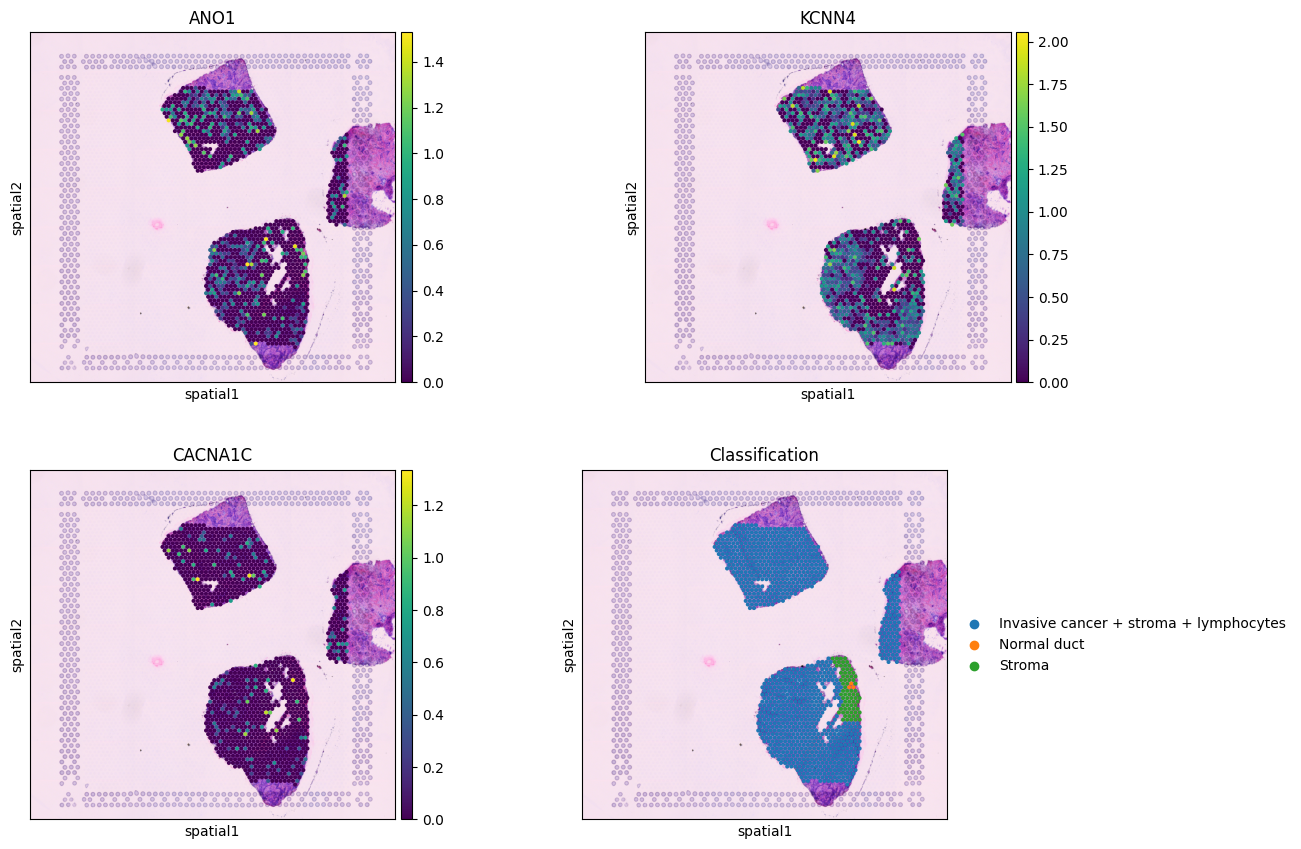

In [17]:
def get_spatial_uns(sample_id, data_dir):
    spatial_dir = data_dir + f'spatial/{sample_id}_spatial/'
    with open(spatial_dir + 'scalefactors_json.json') as f:
        scalefactors = json.load(f)
    image = plt.imread(spatial_dir + 'tissue_hires_image.png')
    return {
        sample_id: {
            'images': {'hires': image},
            'scalefactors': {
                'tissue_hires_scalef': scalefactors['tissue_hires_scalef'],
                'spot_diameter_fullres': scalefactors['spot_diameter_fullres']
            }
        }
    }

# plot ion channels on tissue for CID4465
ion_channels_plot = ['ANO1', 'KCNN4', 'CACNA1C']
present = [g for g in ion_channels_plot if g in adata_sample.var_names]
print(f"Ion channels present: {present}")

sq.pl.spatial_scatter(adata_sample,
                      library_id=sample,
                      color=present + ['Classification'],
                      img=True,
                      size=1.5,
                      ncols=2,
                      save='spatial_ion_channels_CID4465.png')

In [18]:
# compute spatial neighbours graph
sq.gr.spatial_neighbors(adata_sample, coord_type='generic', n_neighs=6)

# compute Moran's I — spatial autocorrelation statistic
sq.gr.spatial_autocorr(adata_sample, mode='moran', n_perms=100, n_jobs=4)

# get top spatially variable genes
svgs = adata_sample.uns['moranI'].sort_values('I', ascending=False)
print("Top 20 spatially variable genes:")
print(svgs.head(20))

INFO     Creating graph using `generic` coordinates and `None` transform and `1` libraries.                        
Adding `adata.obsp['spatial_connectivities']`
       `adata.obsp['spatial_distances']`
       `adata.uns['spatial_neighbors']`


/rds/general/user/ys5320/home/anaconda3/envs/scrna/lib/python3.11/site-packages/scanpy/metrics/_morans_i.py:105: UserWarning: 419 variables were constant, will return nan for these.
  return _MoransI(graph, vals)()


Calculating moran's statistic for `100` permutations using `4` core(s)


  0%|          | 0/100 [00:00<?, ?/s]

/rds/general/user/ys5320/home/anaconda3/envs/scrna/lib/python3.11/site-packages/scanpy/metrics/_morans_i.py:105: UserWarning: 419 variables were constant, will return nan for these.
  return _MoransI(graph, vals)()
/rds/general/user/ys5320/home/anaconda3/envs/scrna/lib/python3.11/site-packages/scanpy/metrics/_morans_i.py:105: UserWarning: 419 variables were constant, will return nan for these.
  return _MoransI(graph, vals)()
/rds/general/user/ys5320/home/anaconda3/envs/scrna/lib/python3.11/site-packages/scanpy/metrics/_morans_i.py:105: UserWarning: 419 variables were constant, will return nan for these.
  return _MoransI(graph, vals)()
/rds/general/user/ys5320/home/anaconda3/envs/scrna/lib/python3.11/site-packages/scanpy/metrics/_morans_i.py:105: UserWarning: 419 variables were constant, will return nan for these.
  return _MoransI(graph, vals)()


Adding `adata.uns['moranI']`
Finish (0:02:36)
Top 20 spatially variable genes:
                  I  pval_norm  var_norm  pval_z_sim  pval_sim   var_sim  \
IGLC2      0.704938        0.0  0.000265         0.0  0.009901  0.000477   
FTH1       0.693881        0.0  0.000265         0.0  0.009901  0.000525   
MTRNR2L12  0.686102        0.0  0.000265         0.0  0.009901  0.000598   
IGHA1      0.675128        0.0  0.000265         0.0  0.009901  0.000464   
MALAT1     0.672661        0.0  0.000265         0.0  0.009901  0.000628   
S100A8     0.666680        0.0  0.000265         0.0  0.009901  0.000579   
IGLC3      0.656677        0.0  0.000265         0.0  0.009901  0.000463   
CD24       0.648842        0.0  0.000265         0.0  0.009901  0.000501   
TMSB10     0.647265        0.0  0.000265         0.0  0.009901  0.000474   
RPL41      0.630815        0.0  0.000265         0.0  0.009901  0.000520   
IGHG3      0.626445        0.0  0.000265         0.0  0.009901  0.000508   
CSN3     

Top SVGs to plot: ['IGLC2', 'FTH1', 'MTRNR2L12', 'IGHA1', 'MALAT1', 'S100A8']


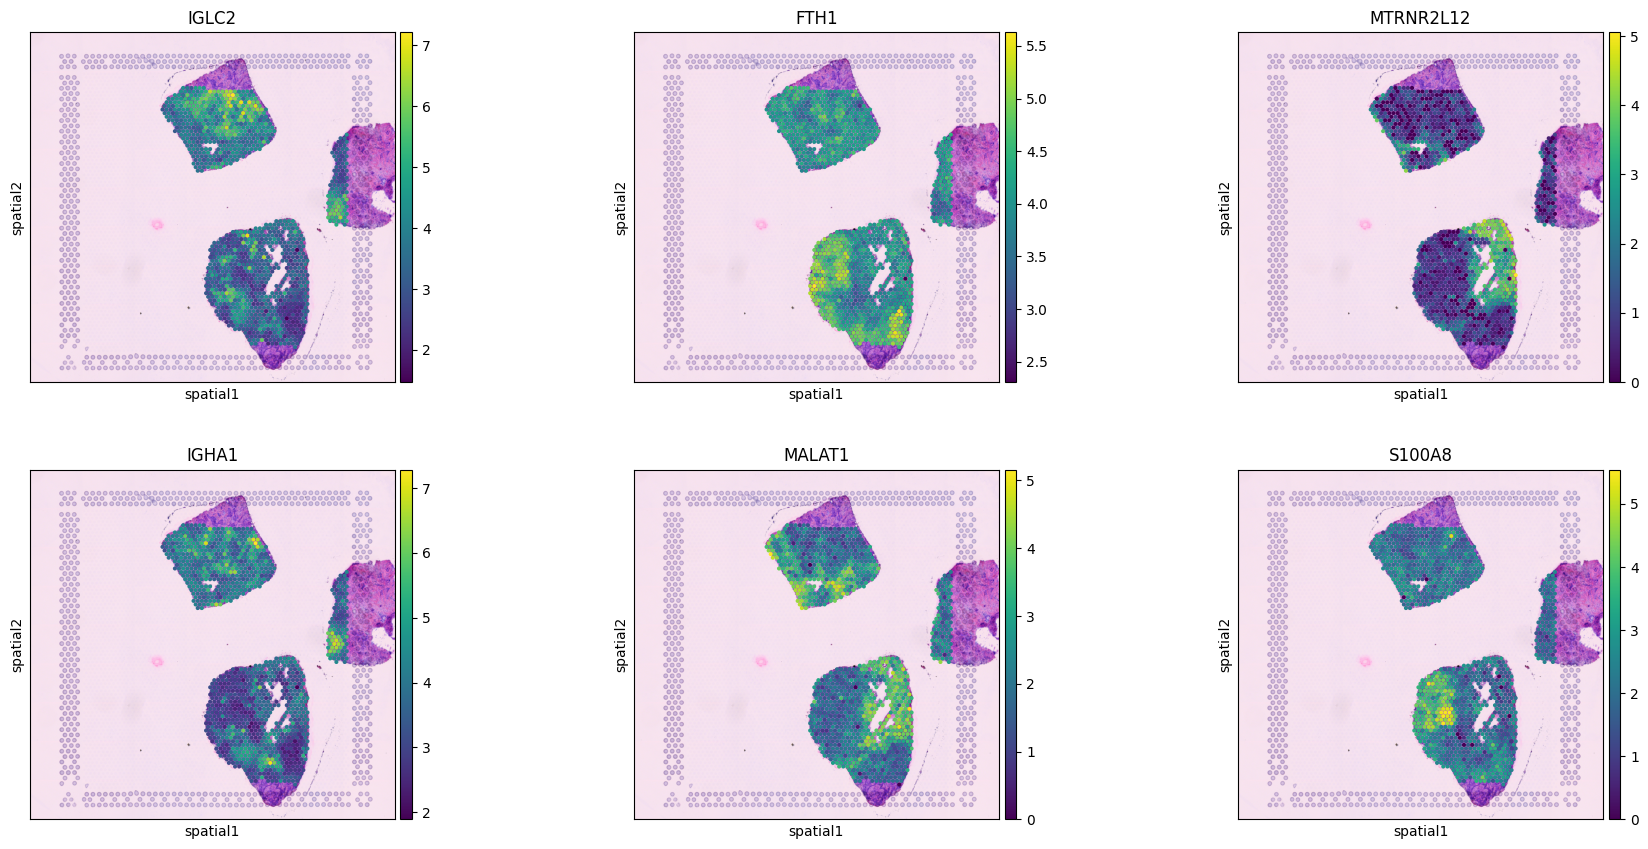

In [19]:
# plot top spatially variable genes on tissue
top_svgs = svgs.head(6).index.tolist()
print(f"Top SVGs to plot: {top_svgs}")

sq.pl.spatial_scatter(adata_sample,
                      library_id=sample,
                      color=top_svgs,
                      img=True,
                      size=1.5,
                      ncols=3,
                      save='spatial_svgs_CID4465.png')

In [20]:
# compare spatially variable genes between TNBC and ER+ samples
# run Moran's I on an ER+ sample
sample_erp = 'CID4290'
adata_erp = adatas[sample_erp].copy()
sc.pp.normalize_total(adata_erp, target_sum=1e4)
sc.pp.log1p(adata_erp)

adata_erp.uns['spatial'] = get_spatial_uns(sample_erp, DATA_DIR)

# compute spatial neighbours and Moran's I
sq.gr.spatial_neighbors(adata_erp, coord_type='generic', n_neighs=6)
sq.gr.spatial_autocorr(adata_erp, mode='moran', n_perms=100, n_jobs=4)

svgs_erp = adata_erp.uns['moranI'].sort_values('I', ascending=False)
print("Top 20 spatially variable genes in ER+:")
print(svgs_erp.head(20)[['I']])

normalizing counts per cell
    finished (0:00:01)
INFO     Creating graph using `generic` coordinates and `None` transform and `1` libraries.                        
Adding `adata.obsp['spatial_connectivities']`
       `adata.obsp['spatial_distances']`
       `adata.uns['spatial_neighbors']`


/rds/general/user/ys5320/home/anaconda3/envs/scrna/lib/python3.11/site-packages/scanpy/metrics/_morans_i.py:105: UserWarning: 381 variables were constant, will return nan for these.
  return _MoransI(graph, vals)()


Calculating moran's statistic for `100` permutations using `4` core(s)


  0%|          | 0/100 [00:00<?, ?/s]

/rds/general/user/ys5320/home/anaconda3/envs/scrna/lib/python3.11/site-packages/scanpy/metrics/_morans_i.py:105: UserWarning: 381 variables were constant, will return nan for these.
  return _MoransI(graph, vals)()
/rds/general/user/ys5320/home/anaconda3/envs/scrna/lib/python3.11/site-packages/scanpy/metrics/_morans_i.py:105: UserWarning: 381 variables were constant, will return nan for these.
  return _MoransI(graph, vals)()
/rds/general/user/ys5320/home/anaconda3/envs/scrna/lib/python3.11/site-packages/scanpy/metrics/_morans_i.py:105: UserWarning: 381 variables were constant, will return nan for these.
  return _MoransI(graph, vals)()
/rds/general/user/ys5320/home/anaconda3/envs/scrna/lib/python3.11/site-packages/scanpy/metrics/_morans_i.py:105: UserWarning: 381 variables were constant, will return nan for these.
  return _MoransI(graph, vals)()


Adding `adata.uns['moranI']`
Finish (0:02:42)
Top 20 spatially variable genes in ER+:
                  I
SCGB2A2    0.753750
PI16       0.729605
PIP        0.626852
MALAT1     0.598235
SCGB1D2    0.591597
MT-ATP6    0.566190
SCGB2A1    0.550706
MT-CO3     0.532338
RPL41      0.529095
MT-ND3     0.510156
MTRNR2L12  0.508445
S100A6     0.479577
MT-ND4     0.471170
RPLP1      0.466743
MT-CO1     0.461732
IGKC       0.456941
RPS27      0.453907
MGP        0.435457
CLU        0.428776
MT-ND1     0.419021
